In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Chargement du dataset enrichi
df = pd.read_csv('dvf_bpe_ecole_commerce_sante.csv')

# 2. Vérification des nouvelles colonnes
new_cols = ['dist_com_prox', 'dist_sante_prox', 'dist_vie_quartier', 'dist_supermarche', 'dist_hopital']
print(f"Colonnes de services présentes : {[c for c in new_cols if c in df.columns]}")
print(f"Nombre de lignes : {len(df)}")

# 3. Nettoyage rapide (au cas où)
# On s'assure de ne garder que le numérique pour le modèle
target = 'valeur_fonciere'
# On exclut les colonnes de fuite de données et les colonnes textuelles
X = df.select_dtypes(include=[np.number]).drop(columns=[target, 'commune_prix_m2', 'commune_volume'], errors='ignore')
y = df[target]

print(f"Features utilisées pour l'entraînement : {X.columns.tolist()}")

Colonnes de services présentes : ['dist_com_prox', 'dist_sante_prox', 'dist_vie_quartier', 'dist_supermarche', 'dist_hopital']
Nombre de lignes : 4640555
Features utilisées pour l'entraînement : ['surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'annee', 'mois', 'code_departement', 'longitude', 'latitude', 'is_maison', 'is_neuf', 'anciennete_mois', 'dist_primaire', 'dist_college', 'dist_lycee', 'dist_superieur', 'dist_prive', 'marche_primaire', 'dist_com_prox', 'dist_sante_prox', 'dist_vie_quartier', 'dist_supermarche', 'dist_hopital']


In [3]:
# 1. On définit le modèle avec l'early stopping à l'intérieur
model_final = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=9,
    tree_method='hist',
    early_stopping_rounds=50,  # Déplacé ici !
    random_state=42,
    n_jobs=-1
)

print("\n--- Début de l'entraînement ---")

# 2. Le .fit() devient plus simple
model_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# 3. Résultats
y_pred = model_final.predict(X_test)
print(f"\n✅ Score R² final : {r2_score(y_test, y_pred):.4f}")
print(f"✅ Erreur MAE : {mean_absolute_error(y_test, y_pred):.2f} €")


--- Début de l'entraînement ---
[0]	validation_0-rmse:241953.56765
[100]	validation_0-rmse:137214.82788
[200]	validation_0-rmse:131260.35575
[300]	validation_0-rmse:128734.57695
[400]	validation_0-rmse:127081.64505
[500]	validation_0-rmse:126146.40902
[600]	validation_0-rmse:125327.21821
[700]	validation_0-rmse:124775.69528
[800]	validation_0-rmse:124183.85927
[900]	validation_0-rmse:123806.36173
[999]	validation_0-rmse:123536.97992

✅ Score R² final : 0.7537
✅ Erreur MAE : 59899.61 €


<Figure size 1000x800 with 0 Axes>

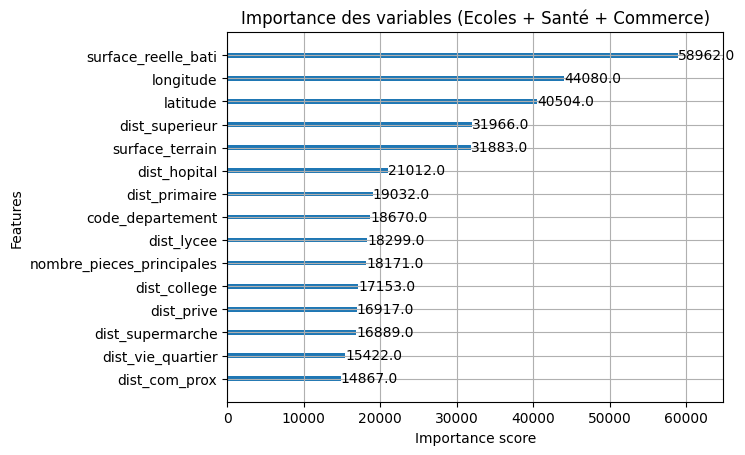

In [4]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_final, max_num_features=15, importance_type='weight')
plt.title("Importance des variables (Ecoles + Santé + Commerce)")
plt.show()

## Passage log

In [5]:
import numpy as np

# 1. Transformation de la cible en Logarithme
# On utilise log1p (log(1+x)) par sécurité pour éviter log(0)
y_log = np.log1p(df['valeur_fonciere'])

# 2. Nouveau Split
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 3. Ré-entraînement du modèle
model_log = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=9,
    tree_method='hist',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

print("Entraînement sur le LOG de la valeur foncière...")
model_log.fit(
    X_train_log, y_train_log,
    eval_set=[(X_test_log, y_test_log)],
    verbose=100
)

# 4. ÉVALUATION (Attention : il faut repasser à l'exponentielle)
y_pred_log = model_log.predict(X_test_log)
y_pred_final = np.expm1(y_pred_log) # On revient en Euros
y_test_final = np.expm1(y_test_log) # On revient en Euros

r2_final = r2_score(y_test_final, y_pred_final)
mae_final = mean_absolute_error(y_test_final, y_pred_final)

print(f"\n--- RÉSULTATS AVEC TRANSFORMATION LOG ---")
print(f"Nouveau Score R² : {r2_final:.4f}")
print(f"Nouvelle Erreur MAE : {mae_final:.2f} €")

Entraînement sur le LOG de la valeur foncière...
[0]	validation_0-rmse:0.72840
[100]	validation_0-rmse:0.41490
[200]	validation_0-rmse:0.39556
[300]	validation_0-rmse:0.38721
[400]	validation_0-rmse:0.38226
[500]	validation_0-rmse:0.37883
[600]	validation_0-rmse:0.37624
[700]	validation_0-rmse:0.37411
[800]	validation_0-rmse:0.37261
[900]	validation_0-rmse:0.37133
[999]	validation_0-rmse:0.37025

--- RÉSULTATS AVEC TRANSFORMATION LOG ---
Nouveau Score R² : 0.7319
Nouvelle Erreur MAE : 59041.10 €


##  Creation variable interraction BPE comme super variables 

In [6]:
# 1. Création des variables d'interaction (Lien Surface / Services)
# On ajoute +1 pour éviter la division par zéro
df['surf_access_sante'] = df['surface_reelle_bati'] / (df['dist_sante_prox'] + 1)
df['surf_access_com'] = df['surface_reelle_bati'] / (df['dist_com_prox'] + 1)

# 2. Gestion du Code Département en catégorie
# On s'assure qu'il est bien en texte d'abord, puis en catégorie
df['code_departement'] = df['code_departement'].astype(str).astype('category')

# 3. Sélection des features (incluant les nouvelles)
target = 'valeur_fonciere'
features_to_drop = [target, 'commune_prix_m2', 'commune_volume']
X = df.select_dtypes(exclude=['object']).drop(columns=features_to_drop, errors='ignore')

# On force explicitement le type category pour XGBoost
X['code_departement'] = df['code_departement']

# 4. Nouveau Split avec la cible en LOG
y_log = np.log1p(df[target])
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

## Entraînement avec support des Catégories


In [7]:
# Configuration optimisée
model_ultra = xgb.XGBRegressor(
    n_estimators=1500,        # On augmente un peu la patience
    learning_rate=0.03,       # On baisse le pas pour être plus précis
    max_depth=10,             # Un peu plus de profondeur pour les interactions
    tree_method='hist',
    enable_categorical=True,  # CRUCIAL pour le code_departement
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

print("Lancement de l'entraînement ultra-précis...")
model_ultra.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# 3. Évaluation finale (retour en Euros)
y_pred_log = model_ultra.predict(X_test)
y_pred_final = np.expm1(y_pred_log)
y_test_final = np.expm1(y_test)

print(f"\n✅ Score R² final : {r2_score(y_test_final, y_pred_final):.4f}")
print(f"✅ Erreur MAE : {mean_absolute_error(y_test_final, y_pred_final):.2f} €")

Lancement de l'entraînement ultra-précis...
[0]	validation_0-rmse:0.73535
[100]	validation_0-rmse:0.41922
[200]	validation_0-rmse:0.39790
[300]	validation_0-rmse:0.38854
[400]	validation_0-rmse:0.38226
[500]	validation_0-rmse:0.37789
[600]	validation_0-rmse:0.37509
[700]	validation_0-rmse:0.37298
[800]	validation_0-rmse:0.37119
[900]	validation_0-rmse:0.36975
[1000]	validation_0-rmse:0.36866
[1100]	validation_0-rmse:0.36769
[1200]	validation_0-rmse:0.36688
[1300]	validation_0-rmse:0.36616
[1400]	validation_0-rmse:0.36562
[1499]	validation_0-rmse:0.36498

✅ Score R² final : 0.7438
✅ Erreur MAE : 57697.11 €


## Passer sur CatBoost

In [9]:
!pip install catboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 4.0 MB/s eta 0:00:26
    --------------------------------------- 1.3/101.7 MB 4.2 MB/s eta 0:00:25
    --------------------------------------- 2.1/101.7 MB 4.1 MB/s eta 0:00:25
   - -------------------------------------- 2.9/101.7 MB 4.1 MB/s eta 0:00:25
   - -------------------------------------- 3.7/101.7 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 4.5/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 5.5/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 6.3/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 7.1/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.1/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.9/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 9.7/101.7 MB 4.0 MB/s eta 0


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import gc
import numpy as np
from catboost import CatBoostRegressor

# 1. NETTOYAGE RADICAL DE LA MÉMOIRE
# On transforme les colonnes numériques en float32 pour gagner 50% de RAM
for col in X.select_dtypes(include=['float64']).columns:
    X[col] = X[col].astype(np.float32)
for col in X.select_dtypes(include=['int64']).columns:
    X[col] = X[col].astype(np.int32)

# On supprime les vieux objets et on vide la RAM
gc.collect()

# 2. CONFIGURATION "LIGHT" POUR CATBOOST
model_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=7,            # On baisse un peu la profondeur (plus léger en RAM)
    rsm=0.8,            # Ne regarde que 80% des colonnes à chaque arbre
    loss_function='RMSE',
    random_seed=42,
    verbose=100,
    bootstrap_type='Bernoulli', # Plus économe en mémoire
    subsample=0.8,
    allow_writing_files=False
)

print("Lancement de l'entraînement optimisé pour la RAM...")

# On lance le fit
model_cat.fit(
    X_train, y_train,
    cat_features=['code_departement'],
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

Lancement de l'entraînement optimisé pour la RAM...
0:	learn: 0.7319348	test: 0.7318125	best: 0.7318125 (0)	total: 2.3s	remaining: 38m 18s


CatBoostError: bad allocation